In [1]:
!pip install xgboost imbalanced-learn


In [2]:
import pandas as pd
import numpy as np
import matplotlib .pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
import os
os.listdir("/content/drive/MyDrive")


['20220419_204031.jpg',
 'Screenshot_20221223-125103_Samsung Notes.jpg',
 'Screenshot_20230929-132753_GPay.jpg',
 'Screenshot_20231001-142152_GPay.jpg',
 'Screenshot_20231001-143502_GPay.jpg',
 'Ppts of pps',
 'final oops.xlsx',
 '1000073596.pdf',
 'Screenshot_20240930-113118.jpg',
 'report_axionis.pdf',
 'Shreya DBMS assignment 2.pdf',
 'clmsCertificate (3).pdf',
 'ilovepdf_merged.pdf',
 'ilovepdf_merged (1).pdf',
 'ilovepdf_merged (2).pdf',
 'Data-Manipulation-Language-DML-in-Database-Management-Systems[2]  -  Read-Only.pptx',
 'shreyaCodeKata_merged.pdf',
 'WhatsApp Image 2025-01-09 at 23.15.39_74c2ff77.pdf',
 'shreya_23SCSE1010194_25 (1).pdf',
 'shreya_23SCSE1010194_25.pdf',
 'medical documents for leave.pdf',
 'unit 4th os.pdf',
 'unit 3 os .pdf',
 'cache memory.pdf',
 'unit 5th os.pdf',
 'Resume.pdf',
 'edu - parent connect app.jpeg',
 'WhatsApp Image 2025-10-05 at 12.53.20.jpeg',
 'Edu-Parent Connect App.jpeg',
 'Shreya_internship.pdf',
 'JAVA_FULL_STACK_INTERNSHIP(2025-26).pdf'

In [5]:
for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))


/content/drive/MyDrive/Telco Customer Churn.csv


In [6]:
file_path="/content/drive/MyDrive/Telco Customer Churn.csv"
df=pd.read_csv(file_path)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [9]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [10]:
df.shape

(7043, 21)

In [12]:
df["TotalCharges"]=pd.to_numeric(df["TotalCharges"],errors="coerce")

In [13]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [14]:
df.dropna(inplace=True)

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [17]:
for col in df.select_dtypes(include="object"):
  print(f"\nColumn: {col}")
  print(df[col].unique())


Column: customerID
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

Column: gender
['Female' 'Male']

Column: Partner
['Yes' 'No']

Column: Dependents
['No' 'Yes']

Column: PhoneService
['No' 'Yes']

Column: MultipleLines
['No phone service' 'No' 'Yes']

Column: InternetService
['DSL' 'Fiber optic' 'No']

Column: OnlineSecurity
['No' 'Yes' 'No internet service']

Column: OnlineBackup
['Yes' 'No' 'No internet service']

Column: DeviceProtection
['No' 'Yes' 'No internet service']

Column: TechSupport
['No' 'Yes' 'No internet service']

Column: StreamingTV
['No' 'Yes' 'No internet service']

Column: StreamingMovies
['No' 'Yes' 'No internet service']

Column: Contract
['Month-to-month' 'One year' 'Two year']

Column: PaperlessBilling
['Yes' 'No']

Column: PaymentMethod
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

Column: Churn
['No' 'Yes']


In [18]:
for col in df.select_dtypes(include="object"):
  df[col]=df[col].str.strip()


In [19]:
for col in df.columns:
  print(col,df[col].unique())

customerID ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
gender ['Female' 'Male']
SeniorCitizen [0 1]
Partner ['Yes' 'No']
Dependents ['No' 'Yes']
tenure [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26 39]
PhoneService ['No' 'Yes']
MultipleLines ['No phone service' 'No' 'Yes']
InternetService ['DSL' 'Fiber optic' 'No']
OnlineSecurity ['No' 'Yes' 'No internet service']
OnlineBackup ['Yes' 'No' 'No internet service']
DeviceProtection ['No' 'Yes' 'No internet service']
TechSupport ['No' 'Yes' 'No internet service']
StreamingTV ['No' 'Yes' 'No internet service']
StreamingMovies ['No' 'Yes' 'No internet service']
Contract ['Month-to-month' 'One year' 'Two year']
PaperlessBilling ['Yes' 'No']
PaymentMethod ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (autom

In [20]:
for col in df.columns:
    if df[col].dropna().isin(["Yes", "No"]).all():
        df[col] = df[col].map({"Yes": 1, "No": 0})


In [21]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,int64
Dependents,int64
tenure,int64
PhoneService,int64
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [25]:
y=df["Churn"]
x=df.drop("Churn",axis=1)

In [26]:
print(x.shape)
print(y.shape)

(7032, 20)
(7032,)


In [27]:
x.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,int64
Dependents,int64
tenure,int64
PhoneService,int64
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [28]:
x=pd.get_dummies(x,drop_first=True)

In [29]:
x.dtypes

,0
SeniorCitizen,int64
Partner,int64
Dependents,int64
tenure,int64
PhoneService,int64
...,...
Contract_One year,bool
Contract_Two year,bool
PaymentMethod_Credit card (automatic),bool
PaymentMethod_Electronic check,bool


In [30]:
y.value_counts()

,count
Churn,
0,5163
1,1869


In [32]:
df.shape
df["Churn"].unique()


array([0, 1])

In [33]:
df.shape

(7032, 21)

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   int64  
 4   Dependents        7032 non-null   int64  
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   int64  
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   int64  
 17  

In [35]:
df.describe()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,0.482509,0.298493,32.421786,0.903299,0.592719,64.798208,2283.300441,0.265785
std,0.368844,0.499729,0.457629,24.545260,0.295571,0.491363,30.085974,2266.771362,0.441782
min,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,18.250000,18.800000,0.000000
25%,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.587500,401.450000,0.000000
50%,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.350000,1397.475000,0.000000
75%,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.862500,3794.737500,1.000000
max,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,1.000000


In [36]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [37]:
df['Churn'].value_counts()

,count
Churn,
0,5163
1,1869


In [42]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')
df['TotalCharges'].isnull().sum()

np.int64(0)

In [45]:
df['TotalCharges']=df['TotalCharges'].fillna(df['TotalCharges'].median())

In [46]:
df.drop('customerID',axis=1,inplace=True)

In [49]:
df['Churn'].value_counts(normalize=True)

,proportion
Churn,
0,0.734215
1,0.265785


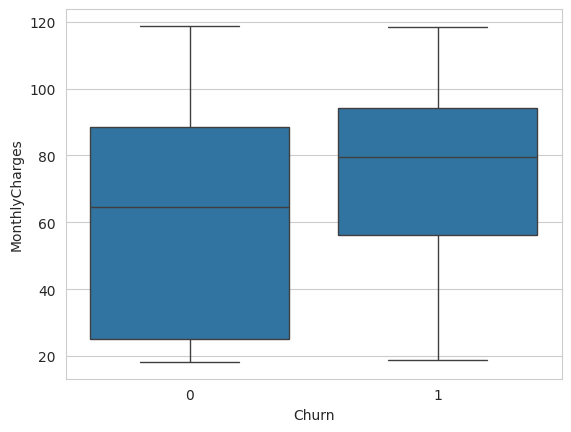

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x='Churn',y='MonthlyCharges',data=df)
plt.show()

In [53]:
pd.crosstab(df['Contract'],df['Churn'],normalize='index')

Churn,0,1
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887228,0.112772
Two year,0.971513,0.028487


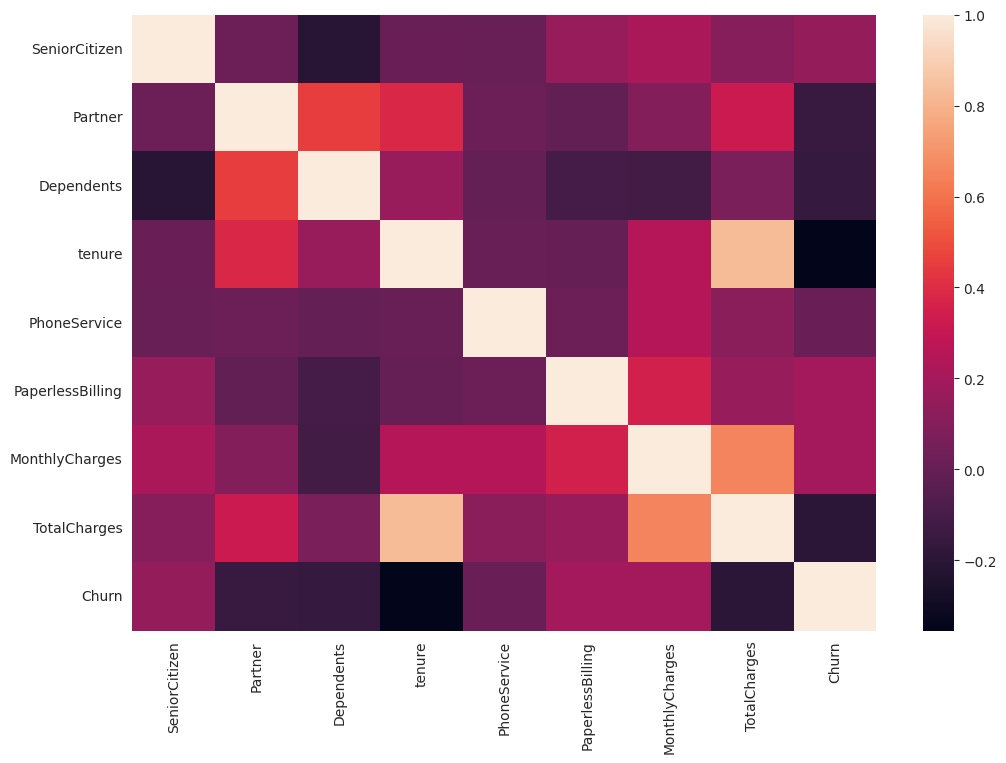

In [57]:
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include=['number']).corr(),annot=False)
plt.show()

In [58]:
x=df.drop('Churn',axis=1)
y=df['Churn']

In [59]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [62]:
x_train=x_train.select_dtypes(include=['number'])
x_test=x_test.select_dtypes(include=['number'])

In [63]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [64]:
from sklearn .linear_model import LogisticRegression

model=LogisticRegression(max_iter=1000,class_weight='balanced')
model.fit(x_train,y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [66]:
y_pred=model.predict(x_test)
y_prob=model.predict_proba(x_test)[:,1]

In [70]:
from sklearn.metrics import confusion_matrix,classification_report,roc_auc_score
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print("ROC AUC:",roc_auc_score(y_test,y_prob))

              precision    recall  f1-score   support

           0       0.89      0.71      0.79      1033
           1       0.49      0.77      0.60       374

    accuracy                           0.72      1407
   macro avg       0.69      0.74      0.69      1407
weighted avg       0.79      0.72      0.74      1407

[[730 303]
 [ 87 287]]
ROC AUC: 0.822425467590891
